# DeepDash — VQ-VAE Training (Colab GPU)

**Runtime → Change runtime type → GPU** before running.

In [ ]:
# Clone repo & install dependencies
!git clone https://github.com/FlorentTariolle/DeepDash.git /content/DeepDash
%cd /content/DeepDash
!pip install torch torchvision opencv-python-headless -q

Cloning into '/content/DeepDash'...
remote: Enumerating objects: 219, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 219 (delta 29), reused 50 (delta 19), pack-reused 156 (from 1)
Receiving objects: 100% (219/219), 377.55 MiB | 26.82 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Updating files: 100% (42/42), done.
/content/DeepDash


In [ ]:
!git pull
!rm -rf data/frames/* data/train data/val

In [ ]:
# Extract frames & split
!python scripts/extract_frames.py --levels 1 2 3 4 5 6
!python scripts/split_dataset.py
!echo "Train:" && ls data/train/ | wc -l && echo "Val:" && ls data/val/ | wc -l

In [ ]:
!python scripts/train_vqvae.py --epochs 100 --batch-size 32 --lr 2e-3

In [ ]:
!python scripts/eval_vae.py --model vqvae --checkpoint checkpoints/vqvae_best.pt


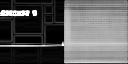
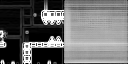
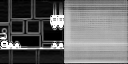
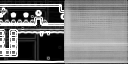
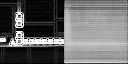
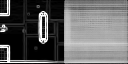
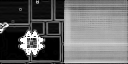
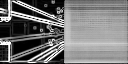

In [ ]:
from IPython.display import display, HTML
import glob, base64

html = '<div style="display:flex;flex-wrap:wrap;gap:10px">'
for f in sorted(glob.glob("eval_output/sample_*.png")):
    with open(f, "rb") as img:
        b64 = base64.b64encode(img.read()).decode()
    html += f'<div><p>{f.split("/")[-1]}</p><img src="data:image/png;base64,{b64}" style="width:384px;image-rendering:pixelated"></div>'
html += '</div>'
display(HTML(html))